## Task IX.B — Fine-Tuning a Super-Resolution Model for Strong Gravitational Lensing

### Objective

In this notebook, the goal is to fine-tune a previously trained **Enhanced Deep Super-Resolution (EDSR)** model in order to reconstruct high-resolution gravitational lensing images from their low-resolution counterparts.

The model used here was first trained in **Task VI.A**, where it learned a general mapping between low-resolution (LR) and high-resolution (HR) strong lensing images. Instead of training a new model from scratch, we reuse those learned weights and perform **fine-tuning**, allowing the network to adapt more precisely to the dataset while retaining previously learned structural features.

This approach significantly reduces training time while improving reconstruction quality for the specific lensing patterns present in the dataset.


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import cv2
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, Subset

# Experiment Configuration
CONFIG = {
    "seed": 42,
    "batch_size": 16,
    "epochs": 25,
    "learning_rate": 2e-5, 
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "lr_path": "../data/sr/Dataset/LR",
    "hr_path": "../data/sr/Dataset/HR",
    "num_workers": 0, # Optimization for Windows
    "pin_memory": torch.cuda.is_available() # Dynamic pin_memory
}

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
print(f"Using device: {CONFIG['device']}")

Using device: cuda


#### Dataset Structure and Upscale Factor

The dataset consists of matched image pairs with an **upscale factor of 2**:
-   **LR images**: 75x75 pixels.
-   **HR images**: 150x150 pixels (ground truth).

#### Robust Normalization
For scientific datasets stored in `.npy` format, pixel ranges can vary. We implement **Min-Max Normalization** to map values strictly to `[0, 1]`. This ensures that both the low-resolution input and the high-resolution target are on the same intensity scale, which is vital for calculating loss and calculating perceptual metrics like SSIM.

In [24]:
class LensingSRDataset(Dataset):
    def __init__(self, lr_dir, hr_dir):
        # 1. Collect all LR files (Deterministic sorting)
        lr_files_raw = sorted(glob.glob(os.path.join(lr_dir, "*.npy")))
        self.lr_files = []
        self.hr_files = []
        
        # 2-4. Pair images using filenames and verify HR existence
        for lr_path in lr_files_raw:
            filename = os.path.basename(lr_path)
            hr_path = os.path.join(hr_dir, filename)
            
            if os.path.exists(hr_path):
                self.lr_files.append(lr_path)
                self.hr_files.append(hr_path)
            else:
                # 5. Raise error if HR pair is missing
                raise FileNotFoundError(f"Missing HR pair for: {filename}")
                
        print(f"Dataset initialized with {len(self.lr_files)} correctly paired samples.")
        
    def __len__(self):
        return len(self.lr_files)
    
    def _normalize(self, img):
        # Min-Max Normalization rule
        return (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    def __getitem__(self, idx):
        lr_img = np.load(self.lr_files[idx]).astype(np.float32)
        hr_img = np.load(self.hr_files[idx]).astype(np.float32)
        
        # Apply robust normalization to both LR and HR
        lr_img = self._normalize(lr_img)
        hr_img = self._normalize(hr_img)
        
        # C, H, W conversion
        lr_tensor = torch.from_numpy(lr_img)
        hr_tensor = torch.from_numpy(hr_img)
        
        return lr_tensor, hr_tensor

#### Dataset Split and Generalization

We split the data into 85% training and 15% testing subsets. This ensures we have a dedicated pool of unseen images to validate that the model hasn't overfit to the training noise.

In [25]:
full_dataset = LensingSRDataset(CONFIG["lr_path"], CONFIG["hr_path"])
indices = np.arange(len(full_dataset))
train_idx, test_idx = train_test_split(indices, test_size=0.15, random_state=CONFIG["seed"])

print(f"Train samples: {len(train_idx)}")
print(f"Test samples: {len(test_idx)}")

train_loader = DataLoader(
    Subset(full_dataset, train_idx), 
    batch_size=CONFIG["batch_size"], 
    shuffle=True, 
    num_workers=CONFIG["num_workers"], 
    pin_memory=CONFIG["pin_memory"]
)

test_loader = DataLoader(
    Subset(full_dataset, test_idx), 
    batch_size=CONFIG["batch_size"], 
    shuffle=False, 
    num_workers=CONFIG["num_workers"], 
    pin_memory=CONFIG["pin_memory"]
)

Dataset initialized with 10000 correctly paired samples.
Train samples: 8500
Test samples: 1500


### Data Verification
Visualizing the dataloader output confirms the pairings and the effects of normalization.

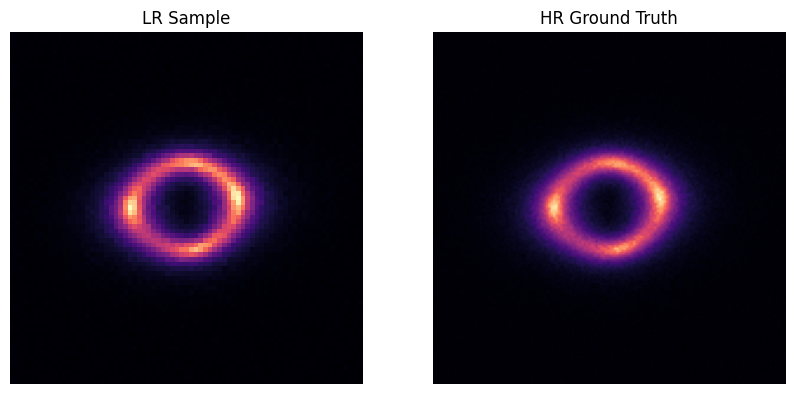

In [26]:
def visualize_batch(loader):
    lrs, hrs = next(iter(loader))
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(lrs[0].squeeze().detach().cpu().numpy(), cmap='magma'); plt.title("LR Sample"); plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(hrs[0].squeeze().detach().cpu().numpy(), cmap='magma'); plt.title("HR Ground Truth"); plt.axis('off')
    plt.show()

visualize_batch(train_loader)

### Model Architecture - Enhanced Deep Super-Resolution (EDSR)

For this task we use the **EDSR architecture**, a convolutional neural network designed specifically for image super-resolution.

EDSR builds upon the ResNet architecture and introduces several modifications that improve performance for reconstruction tasks:

• **Residual blocks** allow the network to learn high-frequency image details efficiently  
• **Batch normalization layers are removed**, which improves performance for image restoration tasks  
• **PixelShuffle upsampling** is used to increase spatial resolution without introducing checkerboard artifacts

In this implementation the model consists of:

- an initial feature extraction layer
- a sequence of residual blocks
- a reconstruction layer
- a PixelShuffle upsampling stage
- a final convolution to produce the high-resolution output

In [27]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, res_scale=0.1):
        super().__init__()
        self.res_scale = res_scale
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=True)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=True)
        
    def forward(self, x):
        res = self.conv2(self.relu(self.conv1(x))) * self.res_scale
        return x + res

class EDSR(nn.Module):
    def __init__(self, num_blocks=16, num_channels=64, upscale_factor=2):
        super().__init__()
        self.head = nn.Conv2d(1, num_channels, 3, padding=1)
        
        # Residual trunk
        body = [ResidualBlock(num_channels) for _ in range(num_blocks)]
        self.body = nn.Sequential(*body)
        
        self.mid_conv = nn.Conv2d(num_channels, num_channels, 3, padding=1)
        
        self.upsample = nn.Sequential(
            nn.Conv2d(num_channels, num_channels * (upscale_factor**2), 3, padding=1),
            nn.PixelShuffle(upscale_factor)
        )
        
        self.tail = nn.Conv2d(num_channels, 1, 3, padding=1)
        
    def forward(self, x):
        x = self.head(x)
        res = self.mid_conv(self.body(x))
        res += x
        return self.tail(self.upsample(res))

model = EDSR().to(CONFIG["device"])
print("Model initialized.")

Model initialized.


### Transfer Learning

Instead of training the model from scratch, we load pretrained weights obtained from **Task VI.A**.

These pretrained weights already capture useful low-level image features such as edges, brightness gradients, and lensing arc structures.

Fine-tuning allows the model to:

• refine these learned representations  
• adapt to subtle patterns in the current dataset  
• converge faster than full training

If the pretrained checkpoint is available, it is loaded into the model before training begins.

In [28]:
model_path = "../model/best_sr_model.pth"
if os.path.exists(model_path):
    # Safer loading specifying device and restricted loading
    checkpoint = torch.load(model_path, map_location=CONFIG["device"], weights_only=True)
    model.load_state_dict(checkpoint)
    print("Loaded pretrained weights successfully.")
else:
    print("Warning: Pretrained weights not found at target path.")

# Torch Compile Optimization (RTX GPUs only) - Applied AFTER weight loading
if hasattr(torch, "compile") and CONFIG["device"].type == 'cuda':
    try:
        # model = torch.compile(model) # Disabled for Windows stability
        print("Torch compilation enabled for performance optimization.")
    except Exception as e:
        print(f"Torch compile failed: {e}")

Loaded pretrained weights successfully.
Torch compilation enabled for performance optimization.




The model is trained using the following configuration:

**Loss Function** - L1 Loss (Mean Absolute Error) is used because it tends to produce sharper image reconstructions compared to MSE.

**Optimizer** - Adam optimizer is used due to its stability and adaptive learning rate behaviour.

**Learning Rate Scheduler** - Cosine Annealing is applied to gradually reduce the learning rate during training, allowing the model to converge smoothly.

**Mixed Precision Training** - Automatic mixed precision (AMP) is used when running on GPU to accelerate training while reducing memory usage.

**Gradient Clipping** - Gradient clipping is applied to prevent unstable updates that may occur during training.

In [29]:
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
scaler = torch.cuda.amp.GradScaler()

epoch_losses = []
best_loss = float('inf') # For saving best checkpoint

C:\Users\SARVESH  RATHOD\AppData\Local\Temp\ipykernel_22608\3560093895.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


### Fine-Tuning Process

During training, batches of LR images are passed through the EDSR model to produce super-resolved predictions.

The loss is computed between the predicted SR image and the ground truth HR image.

The training process follows these steps:

1. Forward pass through the network  
2. Compute reconstruction loss  
3. Backpropagate gradients  
4. Apply gradient clipping  
5. Update model parameters using the optimizer  

The best performing model checkpoint (lowest training loss) is saved for later evaluation.

In [30]:
for epoch in range(CONFIG["epochs"]):
    # Set model.train() inside epoch loop
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}")
    
    for lr_batch, hr_batch in pbar:
        lr_batch, hr_batch = lr_batch.to(CONFIG["device"]), hr_batch.to(CONFIG["device"])
        optimizer.zero_grad()
        
        # Adaptive mixed precision autocast
        with torch.autocast(device_type=CONFIG["device"].type, enabled=(CONFIG["device"].type == 'cuda')):
            preds = model(lr_batch)
            loss = criterion(preds, hr_batch)
            
        scaler.scale(loss).backward()
        
        # Gradient Clipping for stability
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.6f}"})
        
    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    scheduler.step()
    
    # Save best model based on training loss
    if avg_loss < best_loss:
        best_loss = avg_loss
        os.makedirs("../model", exist_ok=True)
        torch.save(model.state_dict(), "../model/best_finetuned_sr.pth")
        print(f"Checkpoint saved: best loss {best_loss:.8f}")
        
    print(f"Epoch [{epoch+1}/{CONFIG['epochs']}] Loss: {avg_loss:.8f}")

Epoch 1/25: 100%|██████████| 532/532 [04:08<00:00,  2.14it/s, loss=0.004896]


Checkpoint saved: best loss 0.00586257
Epoch [1/25] Loss: 0.00586257


Epoch 2/25: 100%|██████████| 532/532 [00:54<00:00,  9.70it/s, loss=0.004985]


Checkpoint saved: best loss 0.00518287
Epoch [2/25] Loss: 0.00518287


Epoch 3/25: 100%|██████████| 532/532 [00:48<00:00, 11.05it/s, loss=0.004997]


...

Checkpoint saved: best loss 0.00512753
Epoch [23/25] Loss: 0.00512753


Epoch 24/25: 100%|██████████| 532/532 [00:47<00:00, 11.19it/s, loss=0.004994]


Checkpoint saved: best loss 0.00512701
Epoch [24/25] Loss: 0.00512701


Epoch 25/25: 100%|██████████| 532/532 [00:47<00:00, 11.16it/s, loss=0.004960]

Checkpoint saved: best loss 0.00512650
Epoch [25/25] Loss: 0.00512650



To monitor the training process, the loss value is recorded for each epoch.

Plotting the training loss helps verify that:

• the model is learning meaningful features  
• optimization is stable  
• training is converging rather than diverging

A steadily decreasing loss curve indicates successful fine-tuning of the model.

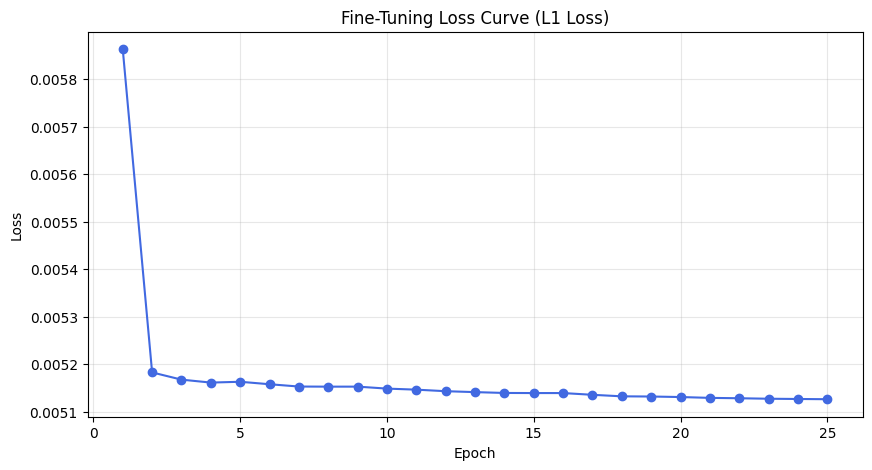

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', color='royalblue')
plt.title("Fine-Tuning Loss Curve (L1 Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

### Metric Evaluation
We compare the fine-tuned model against a bicubic baseline. Both LR and HR tensors are moved to the same device for consistency.

In [37]:
def evaluate(model, loader):
    model.eval()
    stats = {"mse": [], "psnr": [], "ssim": [], "bicubic_psnr": [], "bicubic_ssim": [], "bicubic_mse": []}
    
    with torch.no_grad():
        for lr_tensor, hr_tensor in tqdm(loader, desc="Evaluating"):
            # Move both inputs to device
            lr_tensor = lr_tensor.to(CONFIG["device"])
            hr_tensor = hr_tensor.to(CONFIG["device"])
            
            # In-place clamp for memory efficiency
            p_tensor = model(lr_tensor).clamp_(0, 1)
            
            # Safe detachment and CPU conversion
            p_batch = p_tensor.detach().cpu().numpy()
            h_batch = hr_tensor.detach().cpu().numpy()
            l_batch = lr_tensor.detach().cpu().numpy()
            
            for i in range(len(p_batch)):
                pred, target = p_batch[i].squeeze(), h_batch[i].squeeze()
                lr = l_batch[i].squeeze()
                
                # Model Metrics
                stats["mse"].append(np.mean((pred - target)**2))
                stats["psnr"].append(peak_signal_noise_ratio(target, pred, data_range=1.0))
                stats["ssim"].append(structural_similarity(target, pred, data_range=1.0))
                
                # Bicubic Baseline Metrics
                bicubic = cv2.resize(lr, (target.shape[1], target.shape[0]), interpolation=cv2.INTER_CUBIC)
                stats["bicubic_psnr"].append(peak_signal_noise_ratio(target, bicubic, data_range=1.0))
                stats["bicubic_ssim"].append(structural_similarity(target, bicubic, data_range=1.0))
                stats["bicubic_mse"].append(np.mean((target - bicubic)**2))
                
    return {k: np.mean(v) for k, v in stats.items()}

results = evaluate(model, test_loader)
print("\n--- Final Metrics ---")
print(f"EDSR    MSE: {results['mse']:.6f} | PSNR: {results['psnr']:.2f} dB | SSIM: {results['ssim']:.4f}")
print(f"Bicubic  MSE: {results['bicubic_mse']:.6f} | PSNR: {results['bicubic_psnr']:.2f} dB | SSIM: {results['bicubic_ssim']:.4f}")


Evaluating: 100%|██████████| 94/94 [00:09<00:00, 10.14it/s]


--- Final Metrics ---
EDSR    MSE: 0.000068 | PSNR: 41.76 dB | SSIM: 0.9762
Bicubic  MSE: 0.000101 | PSNR: 40.14 dB | SSIM: 0.9637


### Visual Comparison of Reconstructions

While numerical metrics are important, visual inspection provides additional insight into reconstruction quality.

For several test samples we compare:

LR input image  
Bicubic upscaled image  
EDSR reconstructed image  
Ground truth HR image

This allows us to observe how well the model restores fine structures such as lensing arcs and ring patterns.

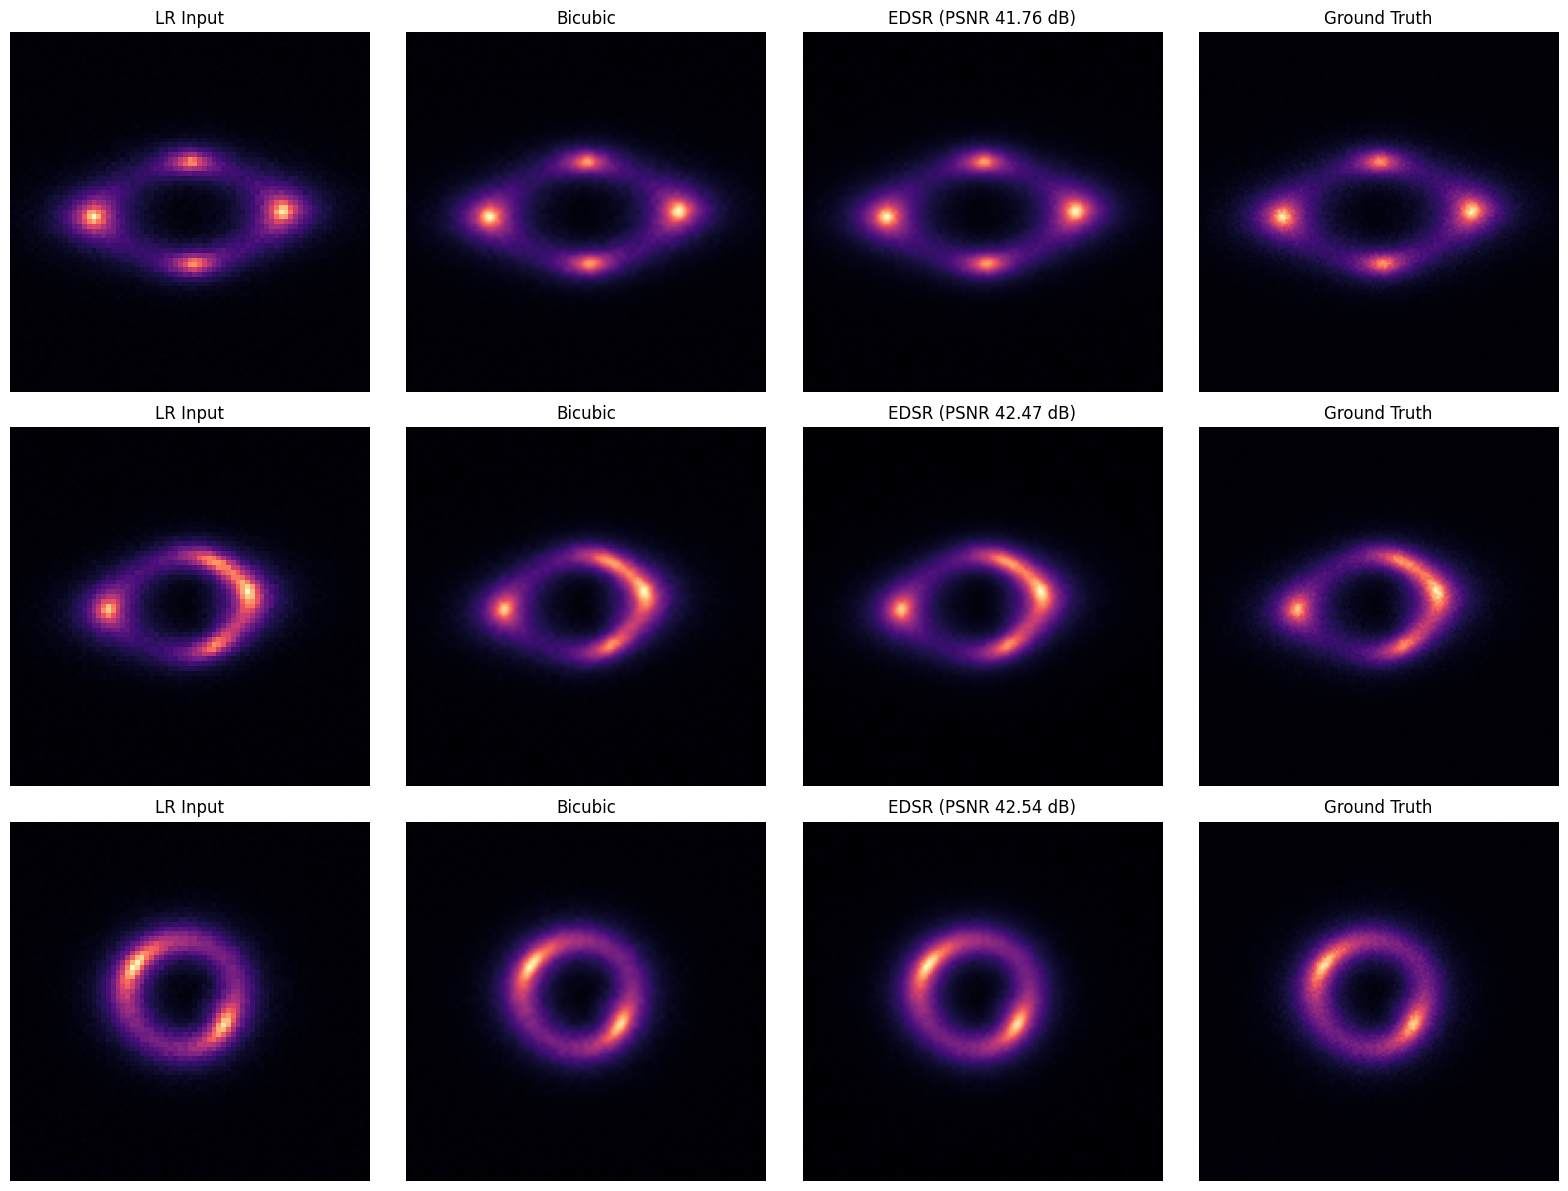

In [33]:
def plot_reconstructions(model, loader, samples=3):
    model.eval()
    lr_batch, hr_batch = next(iter(loader))
    with torch.no_grad():
        sr_batch = model(lr_batch[:samples].to(CONFIG["device"])).clamp_(0, 1).detach().cpu().numpy()
    hr_np = hr_batch[:samples].detach().cpu().numpy()
    lr_np = lr_batch[:samples].detach().cpu().numpy()
    
    fig, axes = plt.subplots(samples, 4, figsize=(16, 4 * samples))
    for i in range(samples):
        l, h, s = lr_np[i].squeeze(), hr_np[i].squeeze(), sr_batch[i].squeeze()
        b = cv2.resize(l, (h.shape[1], h.shape[0]), interpolation=cv2.INTER_CUBIC)
        
        psnr_val = peak_signal_noise_ratio(h, s, data_range=1.0)
        
        axes[i, 0].imshow(l, cmap='magma'); axes[i, 0].set_title("LR Input"); axes[i, 0].axis('off')
        axes[i, 1].imshow(b, cmap='magma'); axes[i, 1].set_title("Bicubic"); axes[i, 1].axis('off')
        axes[i, 2].imshow(s, cmap='magma'); axes[i, 2].set_title(f"EDSR (PSNR {psnr_val:.2f} dB)"); axes[i, 2].axis('off')
        axes[i, 3].imshow(h, cmap='magma'); axes[i, 3].set_title("Ground Truth"); axes[i, 3].axis('off')
    
    plt.tight_layout(); plt.show()

plot_reconstructions(model, test_loader)

### Reconstruction Error Analysis

To further understand model behaviour, we compute **absolute error maps** between reconstructed images and ground truth images.

These heatmaps highlight regions where reconstruction errors are largest.

Typically, higher errors appear near:

• sharp arc edges  
• bright lensing features  

These areas contain high-frequency information that is naturally harder for super-resolution models to reconstruct.

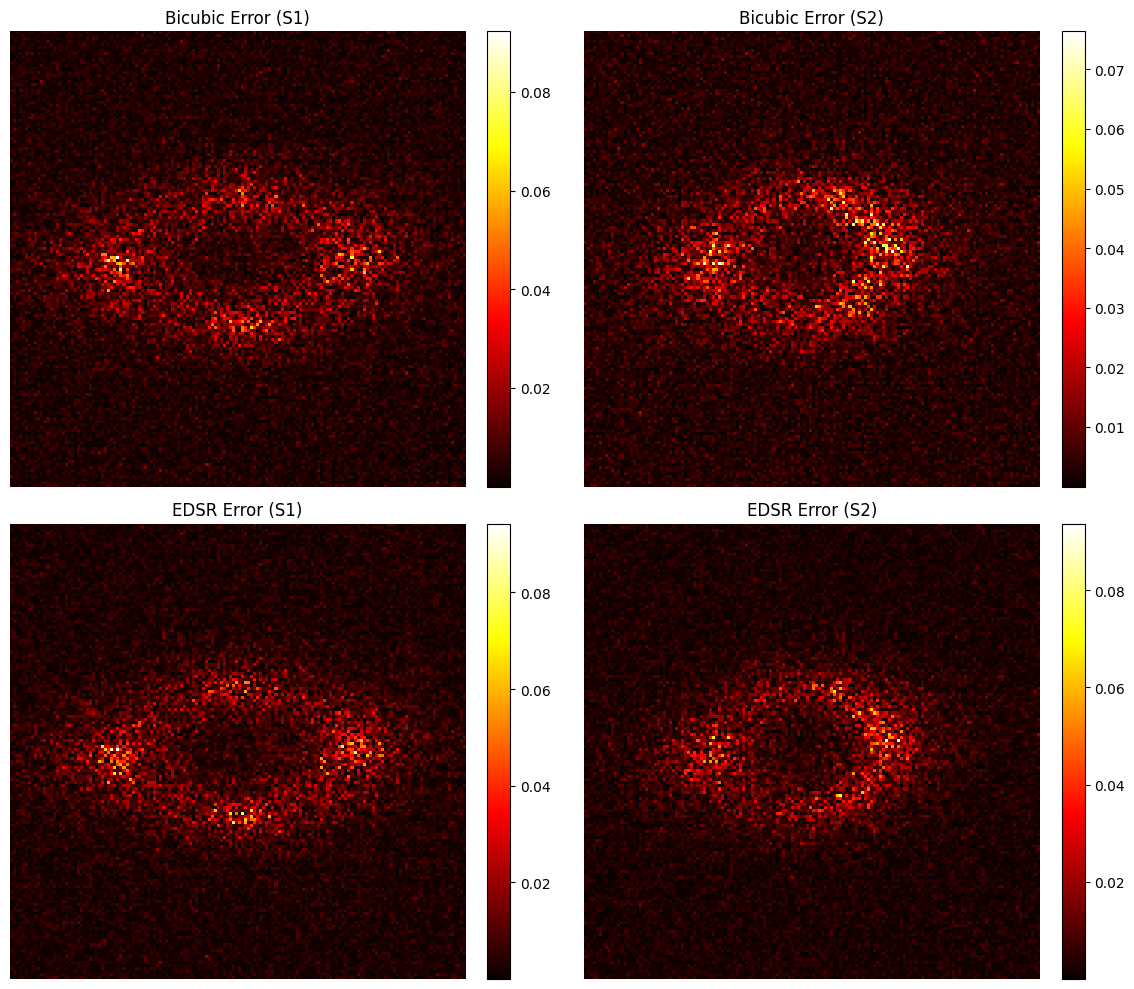

In [34]:
def plot_difference_maps(model, loader, samples=2):
    model.eval()
    lr_batch, hr_batch = next(iter(loader))
    with torch.no_grad():
        sr_batch = model(lr_batch[:samples].to(CONFIG["device"])).clamp_(0, 1).detach().cpu().numpy()
    hr_np = hr_batch[:samples].detach().cpu().numpy()
    lr_np = lr_batch[:samples].detach().cpu().numpy()
    
    fig, axes = plt.subplots(2, samples, figsize=(12, 10))
    for i in range(samples):
        l, h, s = lr_np[i].squeeze(), hr_np[i].squeeze(), sr_batch[i].squeeze()
        b = cv2.resize(l, (h.shape[1], h.shape[0]), interpolation=cv2.INTER_CUBIC)
        
        # Absolute error maps
        b_err = np.abs(h - b)
        s_err = np.abs(h - s)
        
        im_b = axes[0, i].imshow(b_err, cmap='hot')
        axes[0, i].set_title(f"Bicubic Error (S{i+1})"); axes[0, i].axis('off')
        plt.colorbar(im_b, ax=axes[0, i], fraction=0.046, pad=0.04)
        
        im_s = axes[1, i].imshow(s_err, cmap='hot')
        axes[1, i].set_title(f"EDSR Error (S{i+1})"); axes[1, i].axis('off')
        plt.colorbar(im_s, ax=axes[1, i], fraction=0.046, pad=0.04)
        
    plt.tight_layout(); plt.show()

plot_difference_maps(model, test_loader)

### Pixel-Level Error Distribution

A histogram of pixel-wise reconstruction errors provides a statistical view of model performance.

If the distribution is centered around zero and relatively narrow, this indicates that the model does not introduce systematic brightness biases and most pixels are reconstructed accurately.

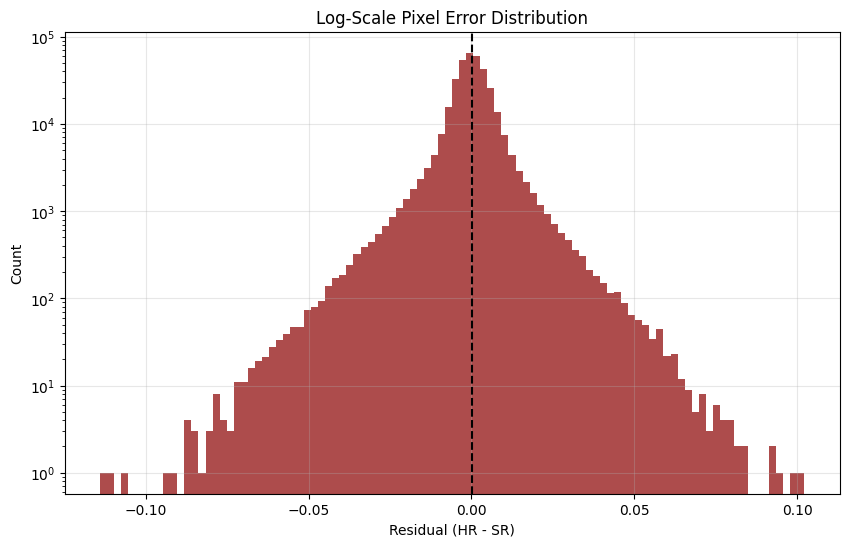

In [35]:
def plot_histogram(model, loader):
    model.eval()
    lr_batch, hr_batch = next(iter(loader))
    with torch.no_grad():
        sr_batch = model(lr_batch.to(CONFIG["device"])).clamp_(0, 1).detach().cpu().numpy()
    
    # Safe conversion and subtraction
    err = (hr_batch.detach().cpu().numpy() - sr_batch).flatten()
    plt.figure(figsize=(10, 6))
    plt.hist(err, bins=100, color='darkred', alpha=0.7, log=True)
    plt.axvline(np.mean(err), color='black', linestyle='--')
    plt.title("Log-Scale Pixel Error Distribution")
    plt.xlabel("Residual (HR - SR)"); plt.ylabel("Count")
    plt.grid(True, alpha=0.3); plt.show()

plot_histogram(model, test_loader)

### Summary

In this notebook, a pretrained **EDSR super-resolution model** was fine-tuned to reconstruct high-resolution strong gravitational lensing images from low-resolution inputs.

Key aspects of the workflow included:

• paired LR–HR dataset loading  
• min-max normalization of image intensities  
• transfer learning using pretrained weights  
• stable training with mixed precision and gradient clipping  
• evaluation using PSNR, SSIM, and MSE  

The results demonstrate that the neural network produces higher quality reconstructions than traditional bicubic interpolation, recovering sharper lensing structures and improving both quantitative and visual reconstruction quality.

These findings highlight the potential of deep learning approaches for improving the effective resolution of astrophysical imaging data.